# Module 8: Exploratory Data Analysis (EDA)

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:
- [ ] Follow a structured EDA workflow: Understand → Clean → Explore → Summarise
- [ ] Calculate and interpret descriptive statistics (mean, median, spread)
- [ ] Detect outliers using the IQR method
- [ ] Analyse correlations between variables
- [ ] Combine Pandas and visualisation skills into a complete data exploration

**⏱ Estimated Time:** 60–75 minutes  
**📋 Prerequisites:** Modules 5–7 (NumPy, Pandas, Visualisation)


## 📦 Environment Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("✅ All libraries loaded!")


✅ All libraries loaded!


In [4]:
# Helper functions — run once
from IPython.display import HTML, display

def info_box(title, content):
    display(HTML(f"""
    <div style="background:#E3F2FD;padding:15px;border-left:5px solid #2196F3;
    margin:10px 0;border-radius:4px;">
    <strong>💡 {title}</strong><br>{content}</div>"""))

def warning_box(title, content):
    display(HTML(f"""
    <div style="background:#FFF3E0;padding:15px;border-left:5px solid #FF9800;
    margin:10px 0;border-radius:4px;">
    <strong>⚠️ {title}</strong><br>{content}</div>"""))

print("✅ Helpers loaded!")


✅ Helpers loaded!


---
## 📊 Our Dataset

We'll create a realistic dataset of **house sales** to practice EDA. This mimics the kind of data you'd encounter in a real project.


In [5]:
# Create a realistic house sales dataset
np.random.seed(42)
n = 200

df = pd.DataFrame({
    "area_sqft":   np.random.randint(500, 3500, n),
    "bedrooms":    np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.25, 0.40, 0.20, 0.10]),
    "age_years":   np.random.randint(0, 60, n),
    "location":    np.random.choice(["Urban", "Suburban", "Rural"], n, p=[0.4, 0.4, 0.2]),
    "garage":      np.random.choice(["Yes", "No"], n, p=[0.6, 0.4]),
})

# Price based on area + bedrooms + noise (realistic relationship)
df["price"] = (
    80 * df["area_sqft"]
    + 15000 * df["bedrooms"]
    - 500 * df["age_years"]
    + np.random.normal(0, 30000, n)
).round(-2)

# Add some missing values (realistic)
mask = np.random.random(n) < 0.05
df.loc[mask, "area_sqft"] = np.nan
mask2 = np.random.random(n) < 0.03
df.loc[mask2, "age_years"] = np.nan

# Add a couple of outlier prices
df.loc[0, "price"] = 1_500_000
df.loc[1, "price"] = 1_800_000

print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset: 200 rows, 6 columns


,area_sqft,bedrooms,age_years,location,garage,price
0,1360.0,5,47.0,Suburban,Yes,1500000.0
1,1794.0,2,20.0,Urban,Yes,1800000.0
2,1630.0,3,38.0,Suburban,No,124600.0
3,1595.0,3,35.0,Suburban,Yes,121600.0
4,2138.0,2,32.0,Urban,Yes,144200.0


---
## 1. The EDA Workflow

EDA follows a simple 4-step process:

**Understand → Clean → Explore → Summarise**

Think of it like arriving at a new house:
1. **Understand** — Walk around, check the rooms (what data do we have?)
2. **Clean** — Fix anything broken, patch holes (handle missing/bad data)
3. **Explore** — Open every drawer, look in every cupboard (visualise patterns)
4. **Summarise** — Write up your findings (key insights)

Let's follow these steps with our house sales data.


---
## Step 1: Understand the Data

Before doing any analysis, get a feel for what you're working with.


In [6]:
# What do the columns look like?
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   area_sqft  185 non-null    float64
 1   bedrooms   200 non-null    int64  
 2   age_years  194 non-null    float64
 3   location   200 non-null    object 
 4   garage     200 non-null    object 
 5   price      200 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 9.5+ KB


In [7]:
# Quick summary of numerical columns
df.describe().round(1)


,area_sqft,bedrooms,age_years,price
count,185.0,200.0,194.0,200.0
mean,2057.6,3.0,29.6,214299.5
std,810.6,1.1,16.8,164147.8
min,521.0,1.0,0.0,13400.0
25%,1460.0,2.0,15.2,144100.0
50%,2000.0,3.0,30.0,195500.0
75%,2764.0,4.0,44.0,262825.0
max,3477.0,5.0,59.0,1800000.0


In [8]:
# Quick summary of categorical columns
print("Location distribution:")
print(df["location"].value_counts())
print()
print("Garage distribution:")
print(df["garage"].value_counts())


Location distribution:
location
Suburban    84
Urban       83
Rural       33
Name: count, dtype: int64

Garage distribution:
garage
Yes    121
No      79
Name: count, dtype: int64


In [9]:
# Check for missing values
print("Missing values per column:")
print(df.isna().sum())
print(f"\nTotal missing: {df.isna().sum().sum()} out of {df.size} values")


Missing values per column:
area_sqft    15
bedrooms      0
age_years     6
location      0
garage        0
price         0
dtype: int64

Total missing: 21 out of 1200 values


---
## Step 2: Clean the Data

We spotted missing values in `area_sqft` and `age_years`. Let's handle them.


In [10]:
# Fill missing values with the median (robust to outliers)
df["area_sqft"] = df["area_sqft"].fillna(df["area_sqft"].median())
df["age_years"] = df["age_years"].fillna(df["age_years"].median())

print("Missing values after cleaning:")
print(df.isna().sum())


Missing values after cleaning:
area_sqft    0
bedrooms     0
age_years    0
location     0
garage       0
price        0
dtype: int64


In [11]:
info_box(
    "Why Median Instead of Mean?",
    "The <b>mean</b> is pulled towards extreme values (outliers). "
    "The <b>median</b> is the middle value, so it's more robust. "
    "For skewed data or data with outliers, median is usually a safer choice for filling gaps."
)


---
## Step 3: Explore the Data

This is where we start looking for patterns, relationships, and oddities.


### 3a. Descriptive Statistics

**Central tendency** tells you where the "middle" of the data is.  
**Spread** tells you how spread out the values are.


In [12]:
# Central tendency and spread for price
price = df["price"]

print(f"Mean price:    £{price.mean():,.0f}")
print(f"Median price:  £{price.median():,.0f}")
print(f"Std deviation: £{price.std():,.0f}")
print(f"Range:         £{price.min():,.0f} — £{price.max():,.0f}")


Mean price:    £214,300
Median price:  £195,500
Std deviation: £164,148
Range:         £13,400 — £1,800,000


In [13]:
# If mean >> median, the data is right-skewed (pulled by high values)
if price.mean() > price.median() * 1.1:
    print("⚠️ Price is RIGHT-SKEWED — a few expensive houses pull the mean up")
    print("   The median is a better measure of a 'typical' house price")
else:
    print("✅ Price is roughly symmetric")


✅ Price is roughly symmetric


### 3b. Distributions — Histograms


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Price distribution
axes[0].hist(df["price"], bins=20, color="#2196F3", edgecolor="white")
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price (£)")

# Area distribution
axes[1].hist(df["area_sqft"], bins=20, color="#4CAF50", edgecolor="white")
axes[1].set_title("Area Distribution")
axes[1].set_xlabel("Area (sq ft)")

# Age distribution
axes[2].hist(df["age_years"], bins=20, color="#FF9800", edgecolor="white")
axes[2].set_title("House Age Distribution")
axes[2].set_xlabel("Age (years)")

plt.tight_layout()
plt.show()


### 3c. Outlier Detection — IQR Method

An **outlier** is a value that is unusually far from the rest of the data.

The **IQR method** is a simple, widely-used approach:
- **Q1** = 25th percentile (lower quarter)
- **Q3** = 75th percentile (upper quarter)
- **IQR** = Q3 − Q1
- An outlier is anything below `Q1 − 1.5 × IQR` or above `Q3 + 1.5 × IQR`


In [14]:
# Detect outliers in price using IQR
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
print(f"Q1: £{Q1:,.0f}  |  Q3: £{Q3:,.0f}  |  IQR: £{IQR:,.0f}")
print(f"Lower bound: £{lower_bound:,.0f}")
print(f"Upper bound: £{upper_bound:,.0f}")
print(f"\nNumber of price outliers: {len(outliers)}")
outliers[["area_sqft", "bedrooms", "price"]].head()


Q1: £144,100  |  Q3: £262,825  |  IQR: £118,725
Lower bound: £-33,988
Upper bound: £440,912

Number of price outliers: 2


,area_sqft,bedrooms,price
0,1360.0,5,1500000.0
1,1794.0,2,1800000.0


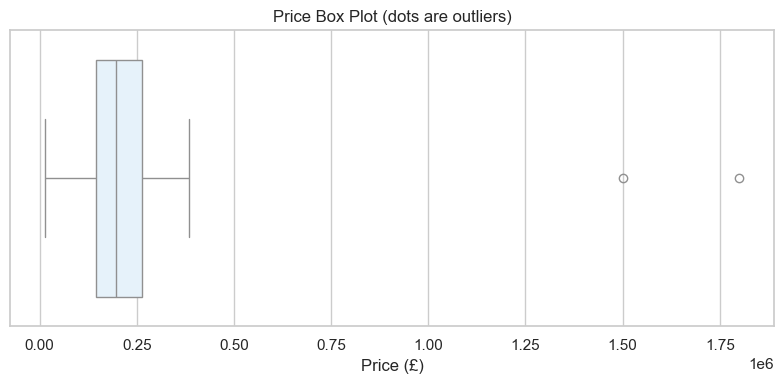

In [15]:
# Visualise outliers with a box plot
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=df["price"], color="#E3F2FD", ax=ax)
ax.set_title("Price Box Plot (dots are outliers)")
ax.set_xlabel("Price (£)")
plt.tight_layout()
plt.show()


### 3d. Correlation Analysis

**Correlation** measures how strongly two numerical variables are related.
- **+1** = perfect positive relationship (as one goes up, so does the other)
- **0** = no relationship
- **−1** = perfect negative relationship (as one goes up, the other goes down)


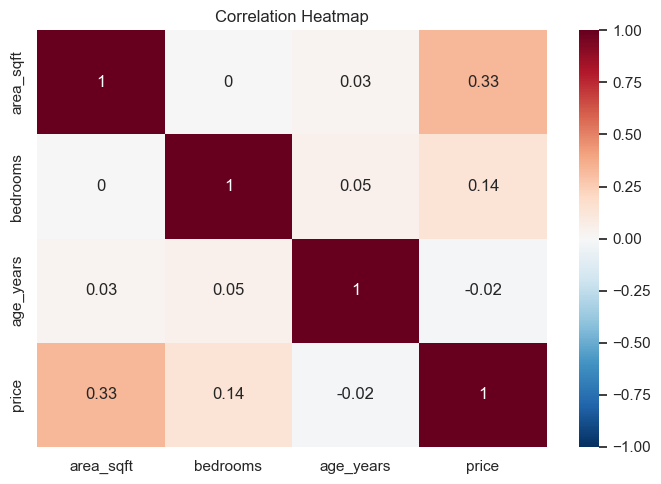

In [16]:
# Correlation matrix
numeric_cols = ["area_sqft", "bedrooms", "age_years", "price"]
corr = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()


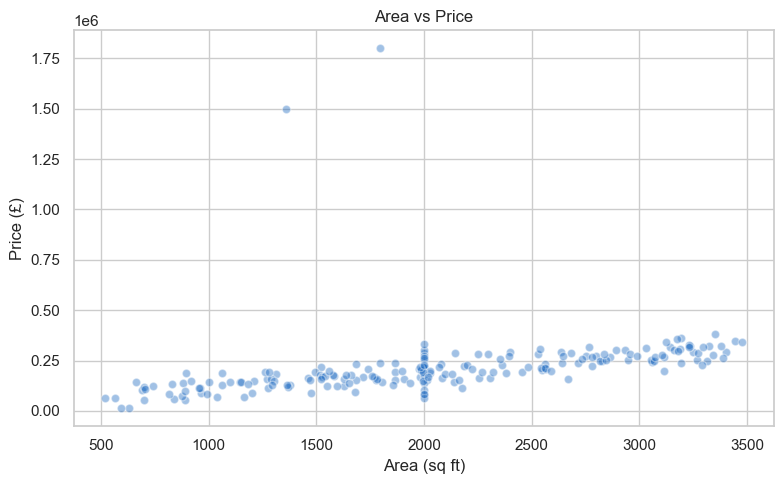

In [17]:
# Scatter: area vs price (should show positive correlation)
fig, ax = plt.subplots()
ax.scatter(df["area_sqft"], df["price"], alpha=0.4, color="#1565C0", edgecolors="white")
ax.set_title("Area vs Price")
ax.set_xlabel("Area (sq ft)")
ax.set_ylabel("Price (£)")
plt.tight_layout()
plt.show()


### 3e. Comparisons Across Categories


/var/folders/hq/v_7wt_d51sn37zqs9vlsf41c0000gn/T/ipykernel_68883/2178602848.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="location", y="price", palette="Set2", ax=axes[0])


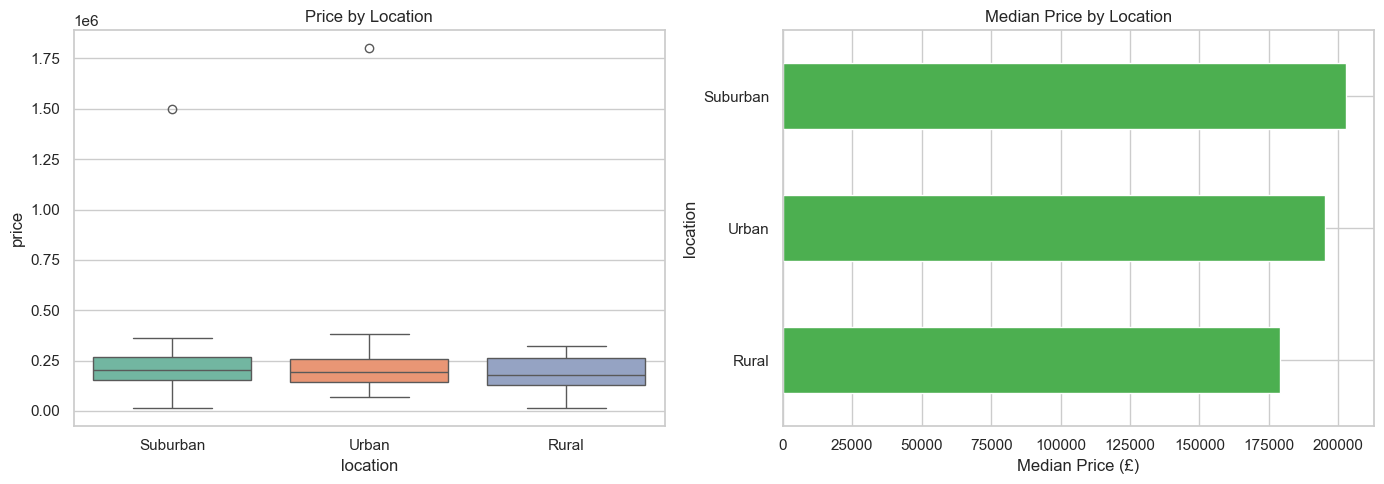

In [18]:
# Price by location
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=df, x="location", y="price", palette="Set2", ax=axes[0])
axes[0].set_title("Price by Location")

# Bar chart of medians
medians = df.groupby("location")["price"].median().sort_values()
medians.plot(kind="barh", ax=axes[1], color="#4CAF50")
axes[1].set_title("Median Price by Location")
axes[1].set_xlabel("Median Price (£)")

plt.tight_layout()
plt.show()


---
## Step 4: Summarise Your Findings

After exploring the data, always write up your key insights. Here's what we found:

**Key Findings:**
1. **Price is right-skewed** — a few very expensive houses pull the mean up. Median is a better summary.
2. **Area is the strongest predictor of price** — larger houses cost more (positive correlation).
3. **House age has a negative relationship with price** — older houses tend to be cheaper.
4. **Outliers exist** — a handful of houses are priced much higher than the rest.
5. **Location matters** — prices vary across Urban, Suburban, and Rural areas.


In [19]:
info_box(
    "EDA is Iterative, Not Linear",
    "In real projects, you'll loop back and forth between these steps. "
    "Cleaning might reveal new patterns. Exploration might uncover data quality issues. "
    "That's perfectly normal!"
)


---
## 🏋️ Practice Exercises


### Exercise 1: Describe a Column ⭐

For the `area_sqft` column, print the mean, median, min, max, and standard deviation. Is it skewed?


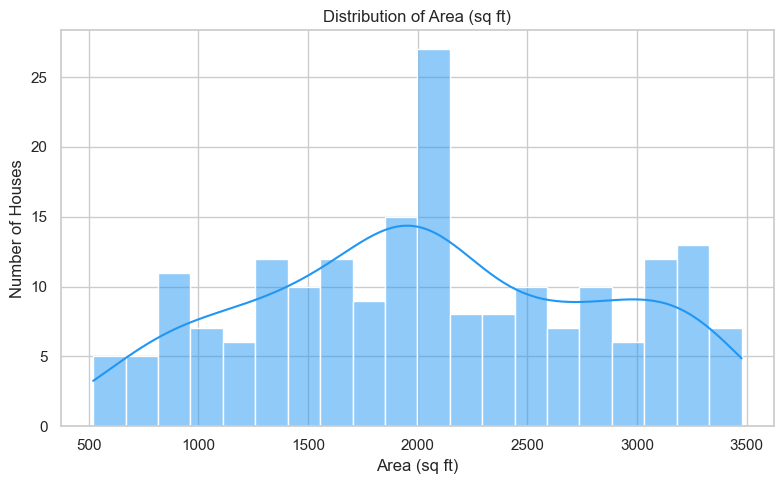

In [22]:
# YOUR CODE HERE
df['area_sqft'].describe()

# It is normally distributed
fig, ax = plt.subplots()
sns.histplot(df['area_sqft'], bins=20, kde=True, color="#2196F3", ax=ax)
ax.set_title("Distribution of Area (sq ft)")
ax.set_xlabel("Area (sq ft)")     
ax.set_ylabel("Number of Houses")
plt.tight_layout()
plt.show()

### Exercise 2: Outlier Detection ⭐⭐

Use the IQR method to detect outliers in the `area_sqft` column. How many outliers are there?


In [ ]:
# YOUR CODE HERE
q1 = df['area_sqft'].quantile(0.25)
q3 = df['area_sqft'].quantile(0.75) 
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['area_sqft'] < lower_bound) | (df['area_sqft'] > upper_bound)]
print(f"Number of outliers in the area_sqft column: {len(outliers)}")
print(f"Bounds: {lower_bound:.0f} — {upper_bound:.0f}")

Number of outliers in the area_sqft column: 0
Bounds: -258 — 4459   


### Exercise 3: Compare Groups ⭐⭐

Create a box plot comparing house prices for homes WITH vs WITHOUT a garage. Which group has higher median prices?


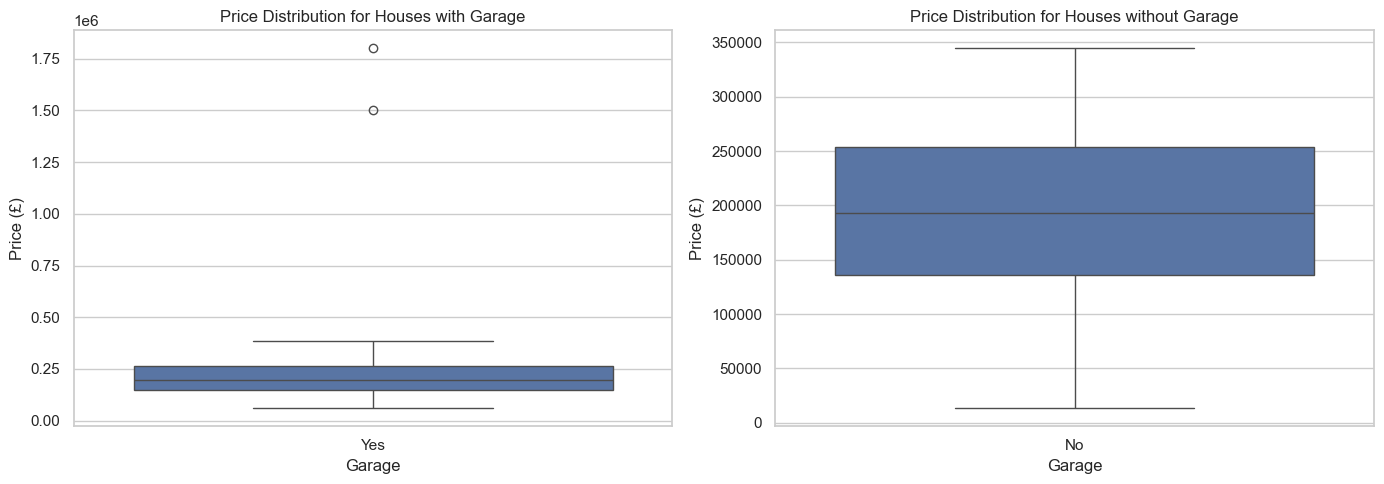

garage
No     192600.0
Yes    196200.0
Name: price, dtype: float64

In [32]:
# YOUR CODE HERE
garage_y = df[df['garage'] == 'Yes']
garage_n = df[df['garage'] == 'No']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=garage_y, x='garage', y='price', ax=axes[0])
axes[0].set_title("Price Distribution for Houses with Garage")
axes[0].set_xlabel("Garage")
axes[0].set_ylabel("Price (£)")

sns.boxplot(data=garage_n, x='garage', y='price', ax=axes[1])
axes[1].set_title("Price Distribution for Houses without Garage")
axes[1].set_xlabel("Garage")
axes[1].set_ylabel("Price (£)")   

plt.tight_layout()
plt.show() 

df.groupby('garage')['price'].median()

---
## 📋 Solutions

<details>
<summary>Click to reveal Exercise 1 solution</summary>

```python
area = df["area_sqft"]
print(f"Mean:   {area.mean():.0f}")
print(f"Median: {area.median():.0f}")
print(f"Min:    {area.min():.0f}")
print(f"Max:    {area.max():.0f}")
print(f"Std:    {area.std():.0f}")

if abs(area.mean() - area.median()) / area.std() < 0.1:
    print("Roughly symmetric")
else:
    print("Skewed")
```

</details>

<details>
<summary>Click to reveal Exercise 2 solution</summary>

```python
Q1 = df["area_sqft"].quantile(0.25)
Q3 = df["area_sqft"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["area_sqft"] < lower) | (df["area_sqft"] > upper)]
print(f"Outliers: {len(outliers)}")
print(f"Bounds: {lower:.0f} — {upper:.0f}")
```

</details>

<details>
<summary>Click to reveal Exercise 3 solution</summary>

```python
fig, ax = plt.subplots()
sns.boxplot(data=df, x="garage", y="price", palette="Set2", ax=ax)
ax.set_title("Price: Garage vs No Garage")
plt.tight_layout()
plt.show()

medians = df.groupby("garage")["price"].median()
print(medians)
```

</details>


---
## 🎯 Key Takeaways

1. **Follow the workflow:** Understand → Clean → Explore → Summarise.
2. **Descriptive stats:** Mean is sensitive to outliers; median is more robust.
3. **Outlier detection:** The IQR method is simple and effective.
4. **Correlation ≠ causation** — just because two things are correlated doesn't mean one causes the other.
5. **Always visualise** — numbers alone can be misleading. Charts reveal the story.
6. **Write up findings** — EDA without a summary is just playing with data.

## ✅ Self-Assessment
- [ ] I can follow the 4-step EDA workflow on a new dataset
- [ ] I can detect outliers using the IQR method
- [ ] I can create and interpret a correlation heatmap

## 📚 Next Steps
- **Next Module:** Module 9 — Statistics & Probability for Data Science
- **Practice:** Download a real dataset from Kaggle and run a complete EDA from scratch
